In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib widget
import seaborn as sns
sns.set_style("whitegrid")

from cone import CircularCone3D
from evaluation import check, check_AH

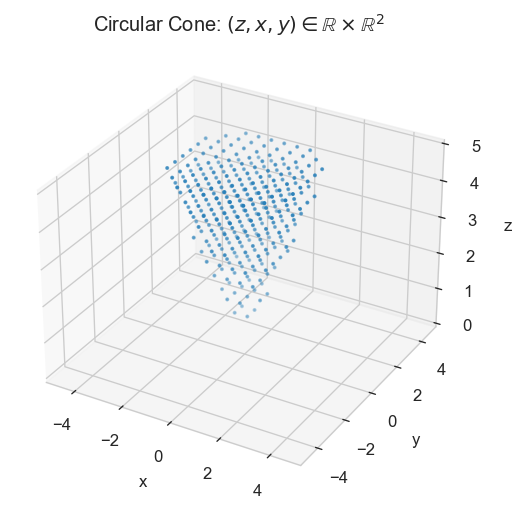

circular cone with angle 30.0 deg
checking...
Not certified.


In [2]:
bdd = 5
num = 20
theta = np.pi/6

cone = CircularCone3D(boundary=bdd, number=num, theta=theta, verbose=True)
points = np.vstack([cone.z, cone.x, cone.y]).T
point_idx = check(points, theta).false_idx

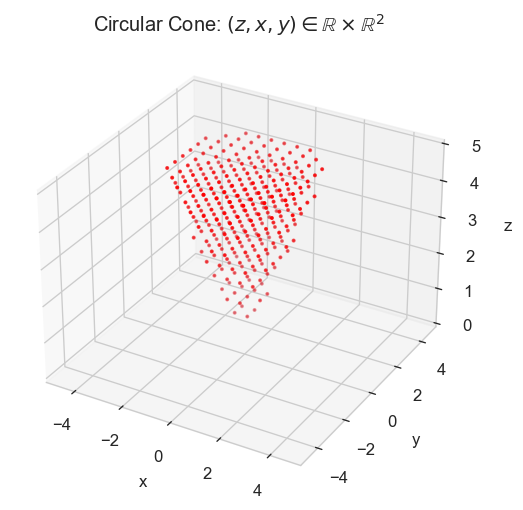

In [3]:
if len(point_idx) != 0:
    false_points = []
    for idx in point_idx:
        p1 = points[idx[0]]
        p2 = points[idx[1]]
        false_points.append([p1[1], p1[2], p1[0]])
        false_points.append([p2[1], p2[2], p2[0]])
    cone.plotPoint(np.array(false_points))

In [4]:
# Ex
k = 500
i = point_idx[k][0]
j = point_idx[k][1]

p1 = points[i]
p2 = points[j]
ex = check_AH(p1, p2, theta, verbose=True)

vector 1: [ 5.         -0.78947368 -2.36842105]
vector 2: [5.         1.84210526 0.26315789]
--------------------------------------------------
vector 1 is in circular cone with theta 30.0 deg
vector 2 is in circular cone with theta 30.0 deg
inverse of vector 1 is not in circular cone with theta 30.0 deg
    x1= 0.48632589533333376
    ||x2||= 0.5734465888155302
    x1 < ||x2||
inverse of vector 2 is not in circular cone with theta 30.0 deg
    x1= 0.2641578181218282
    ||x2||= 0.17239242738829594
    x1 < ||x2||
--------------------------------------------------
A is in circular cone with theta 30.0 deg
H is not in circular cone with theta 30.0 deg
    x1= -1.9111361326227874
    ||x2||= 6.607567782135719
    x1 < ||x2||
--------------------------------------------------
A-H is not in circular cone with theta 30.0 deg
    x1= 6.911136132622787
    ||x2||= 7.668755144371001
    x1 < ||x2||


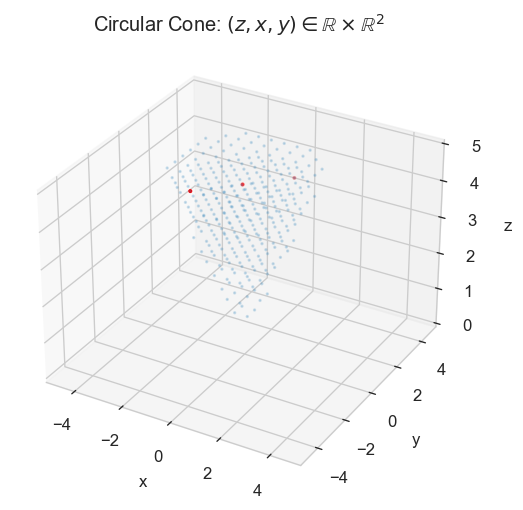

In [5]:
cone.plotPoint(np.array([[ex.vec1[1], ex.vec1[2], ex.vec1[0]],
                         [ex.vec2[1], ex.vec2[2], ex.vec2[0]],
                         [ex.A[1], ex.A[2], ex.A[0]]
                         ]))

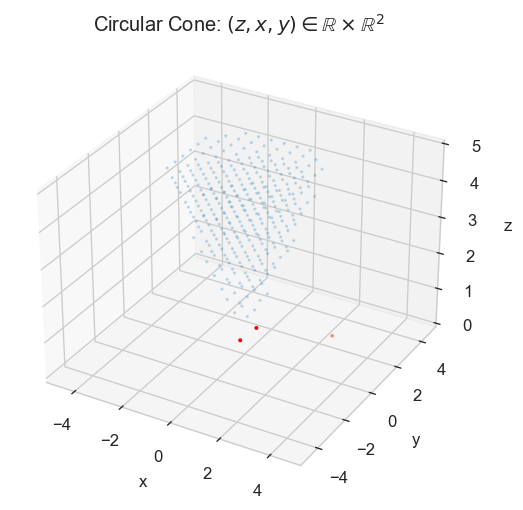

In [6]:
cone.plotPoint(np.array([[ex.spec_inv(ex.vec1)[1], ex.spec_inv(ex.vec1)[2], ex.spec_inv(ex.vec1)[0]],
                         [ex.spec_inv(ex.vec2)[1], ex.spec_inv(ex.vec2)[2], ex.spec_inv(ex.vec2)[0]],
                         [ex.H[1], ex.H[2], ex.H[0]]
                         ]))